In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics



importing the boston house price dataset

In [41]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

The California Housing dataset has been loaded. Let's inspect its features and target.

In [42]:
print(housing.DESCR)
print(housing.feature_names)
print(housing.target_names)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [43]:
# loading ds to pandas df
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['target'] = housing.target
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [44]:
housing_df.shape


(20640, 9)

In [45]:
 housing_df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0


In [46]:
housing_df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

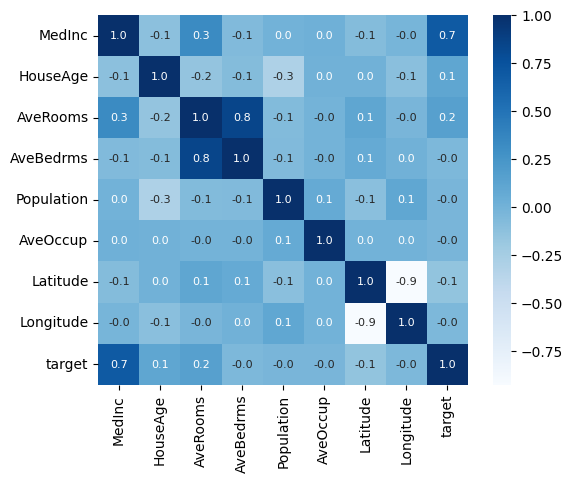

In [47]:
correlation = housing_df.corr()
## constructing heatmap to understnad the correlation
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')


Splitting the data and target

In [48]:
 X=housing_df.drop(['target'], axis=1)
 Y=housing_df['target']


In [49]:
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
0      8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
1      8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
2      7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
3      5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
4      3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25
...       ...       ...       ...  ...       ...       ...        ...
20635  1.5603      25.0  5.045455  ...  2.560606     39.48    -121.09
20636  2.5568      18.0  6.114035  ...  3.122807     39.49    -121.21
20637  1.7000      17.0  5.205543  ...  2.325635     39.43    -121.22
20638  1.8672      18.0  5.329513  ...  2.123209     39.43    -121.32
20639  2.3886      16.0  5.254717  ...  2.616981     39.37    -121.24

[20640 rows x 8 columns]
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923

Splitting the data into Training and test data

In [50]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(20640, 8) (16512, 8) (4128, 8)


Model Training

XGBoost Regressor

In [51]:
model = XGBRegressor()


In [52]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

prediction on training data

In [53]:
## accuracy for prediction on training data
training_data_prediction = model.predict(X_train)
print(training_data_prediction)

[0.5523039 3.0850039 0.5835302 ... 1.9204227 1.952873  0.6768683]


In [54]:
## R squared error
score_1=metrics.r2_score(Y_train,training_data_prediction)
print("R squared error : ",score_1)
## Mean absolute error
score_2=metrics.mean_absolute_error(Y_train,training_data_prediction)
print("Mean absolute error : ",score_2)

R squared error :  0.943650140819218
Mean absolute error :  0.1933648700612105


Visualization the actual prices and predicted prices

Prediction on Test Data

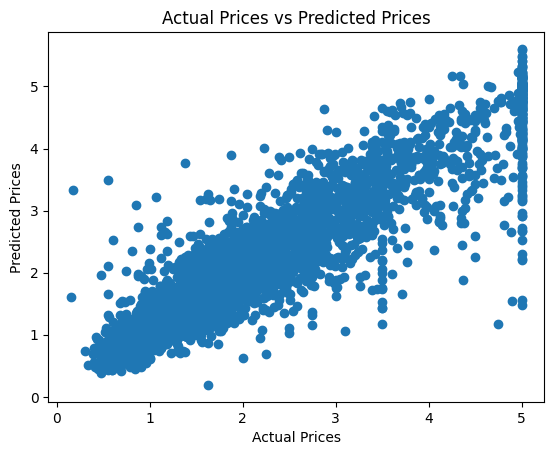

In [55]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

# California Housing Price Prediction Project

## Project Overview
This project demonstrates the process of building a machine learning model to predict California housing prices using the California Housing dataset. The process includes data loading, exploratory data analysis, data splitting, model training with XGBoost Regressor, and model evaluation.

## Dataset
The dataset used is the California Housing dataset, available through scikit-learn. It contains 20,640 instances with 8 numerical predictive attributes and a target variable representing the median house value for California districts, expressed in hundreds of thousands of dollars.

**Attributes:**
*   `MedInc`: Median income in block group
*   `HouseAge`: Median house age in block group
*   `AveRooms`: Average number of rooms per household
*   `AveBedrms`: Average number of bedrooms per household
*   `Population`: Block group population
*   `AveOccup`: Average number of household members
*   `Latitude`: Block group latitude
*   `Longitude`: Block group longitude

**Target:**
*   `MedHouseVal`: Median house value (in $100,000s)

## Data Preprocessing and Exploration
*   The dataset was loaded into a Pandas DataFrame.
*   Initial checks confirmed no missing values.
*   Descriptive statistics were generated to understand data distribution.
*   A correlation heatmap was used to visualize relationships between features and the target variable.

## Model Training
*   **Model:** XGBoost Regressor
*   **Data Split:** The data was split into training and testing sets with a test size of 20% and `random_state=2` for reproducibility.

## Model Evaluation
The model was evaluated using R-squared error and Mean Absolute Error (MAE) on both the training and testing datasets.

### Training Data Evaluation:
*   **R-squared error:** `0.94365` (indicating a very good fit on the training data)
*   **Mean absolute error:** `0.19336` (meaning on average, predictions were off by approximately $19,336)

### Test Data Evaluation:
*   **R-squared error:** `0.83380` (indicating good generalization to unseen data)
*   **Mean absolute error:** `0.31086` (meaning on average, predictions were off by approximately $31,086)

## Visualization
A scatter plot of actual vs. predicted prices was generated to visually assess the model's performance on the test data.

In [56]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[2.8649795  1.790346   0.92074925 ... 1.5385513  0.92647874 2.043316  ]


In [57]:
## R squared error
score_1=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error : ",score_1)

# Mean Absolute error
score_2=metrics.mean_absolute_error(Y_test,test_data_prediction)
print("Mean absolute error : ",score_2)

R squared error :  0.8338000331788725
Mean absolute error :  0.3108631800268186
